# Hogares Conectados (BA + Teléfono)

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Datos
años = [2013, 2015, 2017, 2022, 2024]

# DataFrame con múltiples categorías
df = pd.DataFrame({
    'Año': años,
    'Conectados Nacional': [46.34, 63.47, 69.04, 92.98, 95.73],
    'No conectados Nacional': [53.66, 36.53, 30.96, 7.02, 4.27],
    'Conectados Urbano': [50.94, 67.38, 72.19, 94.20, 96.69],
    'No conectados Urbano': [49.06, 32.62, 27.81, 5.80, 3.31],
    'Conectados Rural': [15.31, 35.65, 47.29, 83.58, 88.36],
    'No conectados Rural': [84.69, 64.35, 52.71, 16.42, 11.64]
})

print(df)

    Año  Conectados Nacional  No conectados Nacional  Conectados Urbano  \
0  2013                46.34                   53.66              50.94   
1  2015                63.47                   36.53              67.38   
2  2017                69.04                   30.96              72.19   
3  2022                92.98                    7.02              94.20   
4  2024                95.73                    4.27              96.69   

   No conectados Urbano  Conectados Rural  No conectados Rural  
0                 49.06             15.31                84.69  
1                 32.62             35.65                64.35  
2                 27.81             47.29                52.71  
3                  5.80             83.58                16.42  
4                  3.31             88.36                11.64  


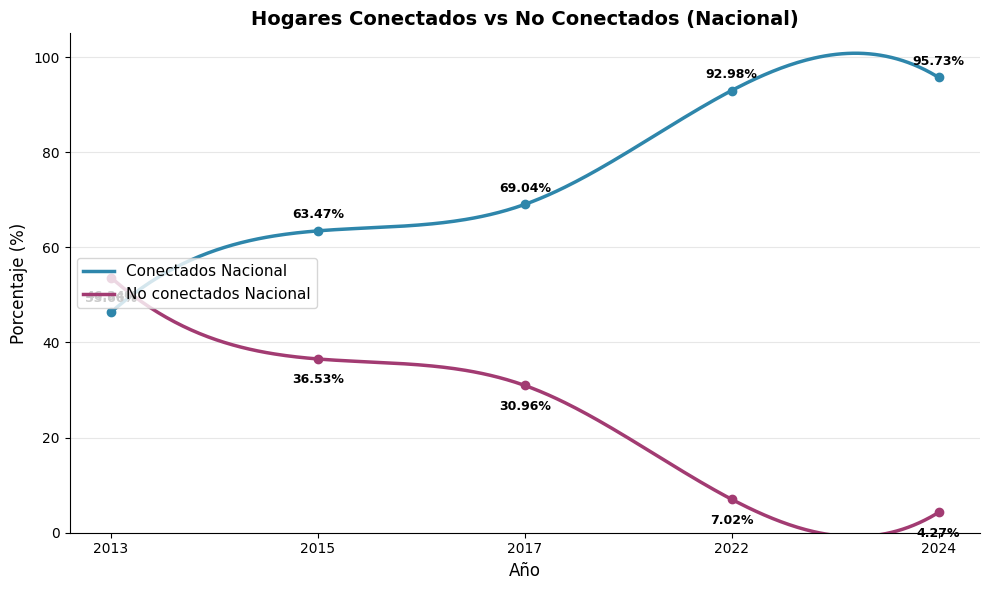

In [26]:
# Gráfico líneas suavizadas
from scipy.interpolate import make_interp_spline

plt.figure(figsize=(10, 6))

# Preparar datos para interpolación
x = np.array(range(len(df)))
y_conectados = np.array(df['Conectados Nacional'])
y_no_conectados = np.array(df['No conectados Nacional'])

# Crear spline suavizado
spl_conectados = make_interp_spline(x, y_conectados, k=3)
spl_no_conectados = make_interp_spline(x, y_no_conectados, k=3)

# Puntos suavizados
x_smooth = np.linspace(x.min(), x.max(), 300)
y_smooth_conectados = spl_conectados(x_smooth)
y_smooth_no_conectados = spl_no_conectados(x_smooth)

# Graficar
plt.plot(x_smooth, y_smooth_conectados, label='Conectados Nacional', linewidth=2.5, color='#2E86AB')
plt.plot(x_smooth, y_smooth_no_conectados, label='No conectados Nacional', linewidth=2.5, color='#A23B72')

plt.title('Hogares Conectados vs No Conectados (Nacional)', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xticks(range(len(df)), df['Año'].astype(str))
plt.grid(True, alpha=0.3, axis='y')
plt.ylim(0, 105)
plt.legend(loc='center left', fontsize=11)

# Eliminar spines
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Etiquetas en puntos originales
for i, (v_con, v_no) in enumerate(zip(y_conectados, y_no_conectados)):
    plt.plot(i, v_con, 'o', color='#2E86AB', markersize=6)
    plt.plot(i, v_no, 'o', color='#A23B72', markersize=6)
    plt.text(i, v_con + 2, f'{v_con:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    plt.text(i, v_no - 3, f'{v_no:.2f}%', ha='center', va='top', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()